# Drzewa decyzyjne

słowa kluczowe: drzewo decyzyjne, klasyfikacja wieloklasowa, indeks Giniego, podział rekurencyjny, macierz pomyłek

Model drzewa decyzyjnego polega na rekurencyjnym podziale przestrzeni cech. W każdym kroku wybierana jest zmienna i punkt podziału, które najlepiej separuja klasy danych.

Celem jest minimalizacja miary niejednorodności, np. indeksu Giniego:
$$G=1-\sum_{k=1}^{K}p_{k}^{2},$$
gdzie $p_{k}$ oznacza udział obserwacji z klasy k w danym weźle drzewa.

Ostateczna predykcja wykonywana jest poprzez przypisanie obserwacji do odpowiedniego liścia drzewa decyzyjnego. Zaletą tego modelu jest wysoka interpretowalność i brak konieczności wstępnego skalowania danych.

### Import bibliotek

In [115]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

### Wczytywanie danych

In [116]:
pokemony = pd.read_csv("pokemon.csv")
pokemony.head()

,name,pokemonid,formid,formname,gen,release,type1,type2,species,height,...,defense,spatk,spdef,speed,ev_hp,ev_attack,ev_defense,ev_spatk,ev_spdef,ev_speed
0,bulbasaur,bulbasaur,NaN,NaN,1,red-blue,grass,poison,Seed,0.7,...,49,65,65,45,NaN,NaN,NaN,1.0,NaN,NaN
1,ivysaur,ivysaur,NaN,NaN,1,red-blue,grass,poison,Seed,1.0,...,63,80,80,60,NaN,NaN,NaN,1.0,1.0,NaN
2,venusaur,venusaur,NaN,NaN,1,red-blue,grass,poison,Seed,2.0,...,83,100,100,80,NaN,NaN,NaN,2.0,1.0,NaN
3,venusaur-mega,venusaur,mega,Mega Venusaur,6,x-y,grass,poison,Seed,2.4,...,123,122,120,80,NaN,NaN,NaN,2.0,1.0,NaN
4,charmander,charmander,NaN,NaN,1,red-blue,fire,NaN,Lizard,0.6,...,43,60,50,65,NaN,NaN,NaN,NaN,NaN,1.0


### Tworzenie grup

In [117]:
type_to_group = {
    "water": "sredniaki",
    "poison": "sredniaki",
    "grass": "sredniaki",
    "ice": "sredniaki",
    "normal": "sredniaki",
    "bug": "sredniaki",

    "dragon": "elita",

    "electric": "specjalni",
    "psychic": "specjalni",
    "fairy": "specjalni",
    "ghost": "specjalni",
    "fire": "specjalni",

    "fighting": "agresorzy",
    "dark": "agresorzy",
    "flying": "agresorzy",

    "ground": "grubole",
    "rock": "grubole",
    "steel": "grubole",
}
pokemony["group"] = pokemony["type1"].str.lower().map(type_to_group)
#usunięcie pustych grup
pokemony = pokemony.dropna(subset=["group"])
pokemony["group"].value_counts()

group
sredniaki    580
specjalni    310
grubole      160
agresorzy    116
elita         49
Name: count, dtype: int64

### Zmienne

In [118]:
pokemonyDrzewo = pokemony.copy()
pokemonyDrzewo = pokemony.dropna(subset=[
    "hp",
    "attack",
    "defense",
    "spatk",
    "spdef",
    "speed",
    "height",
    "weight",
    "catch_rate",
    "base_exp",
    "egg_cycles",
    "group"
])

cechy = pokemonyDrzewo[[
    "hp",
    "attack",
    "defense",
    "spatk",
    "spdef",
    "speed",
    "height",
    "weight",
    "catch_rate",
    "base_exp",
    "egg_cycles"
]]

etykieta = pokemonyDrzewo["group"]

### Podział danych na zbiór treningowy i testowy
##### Dane zostały podzielone na zbiór treningowy (70%) oraz testowy (30%) w celu oceny skuteczności modelu.

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    cechy,
    etykieta,
    test_size=0.3,
    random_state=42
)
cechy.isna().sum()

hp            0
attack        0
defense       0
spatk         0
spdef         0
speed         0
height        0
weight        0
catch_rate    0
base_exp      0
egg_cycles    0
dtype: int64

### Model drzewa
##### Zastosowaliśmy model drzewa decyzyjnego z ograniczoną głębokością, aby zapobiec przetrenowaniu modelu.

In [120]:
tree_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=2,
    random_state=42)
tree_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

### Macierz błędów klasyfikacji dla zbioru treningowego

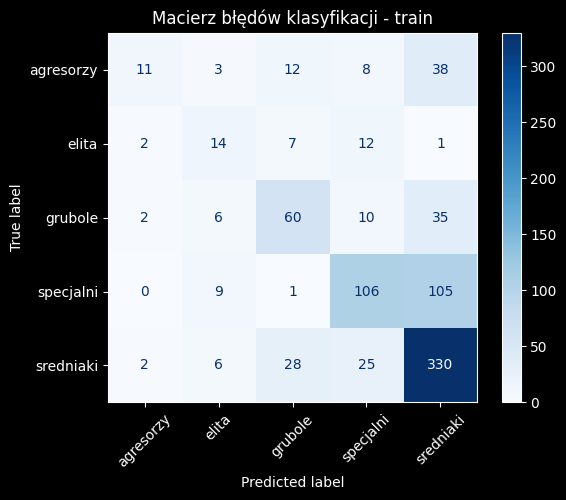

In [121]:
y_pred_train = tree_model.predict(X_train)
disp = ConfusionMatrixDisplay.from_predictions(
    y_train,
    y_pred_train,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji - train")
plt.savefig("confusion_matrix_train_drzewo.png", dpi=300, bbox_inches="tight")
plt.show()

### Dokładność modelu zbiór - testowy

In [122]:
y_pred = tree_model.predict(X_test)

In [123]:
print("Accuracy:", accuracy_score(y_test, y_pred))
procent = accuracy_score(y_test, y_pred) * 100
print(f"Procent poprawnych wyników: {procent:.2f}%")


Accuracy: 0.49162011173184356
Procent poprawnych wyników: 49.16%


In [124]:
wyniki = X_test.copy()

wyniki["prawdziwa_grupa"] = y_test.values
wyniki["przewidziana_grupa"] = y_pred

wyniki["pokemon"] = pokemony.loc[
    X_test.index,
    "name"
].values

print(
    wyniki[
        ["pokemon", "prawdziwa_grupa", "przewidziana_grupa"]
    ].head(20)
)

           pokemon prawdziwa_grupa przewidziana_grupa
953      pheromosa       sredniaki          specjalni
247          yanma       sredniaki          sredniaki
260         pineco       sredniaki          sredniaki
155         horsea       sredniaki          sredniaki
566      rhyperior         grubole            grubole
549   lucario-mega       agresorzy          specjalni
803        flabebe       specjalni          sredniaki
58       vileplume       sredniaki          sredniaki
753       braviary       sredniaki          sredniaki
644         audino       sredniaki          sredniaki
613       oshawott       sredniaki          sredniaki
746      druddigon           elita            grubole
716       frillish       sredniaki          sredniaki
572        leafeon       sredniaki            grubole
380       meditite       agresorzy          sredniaki
70         persian       sredniaki          sredniaki
523       drifloon       specjalni            grubole
823        malamar       agr

### Macierz błędów klasyfikacji dla zbioru testowego

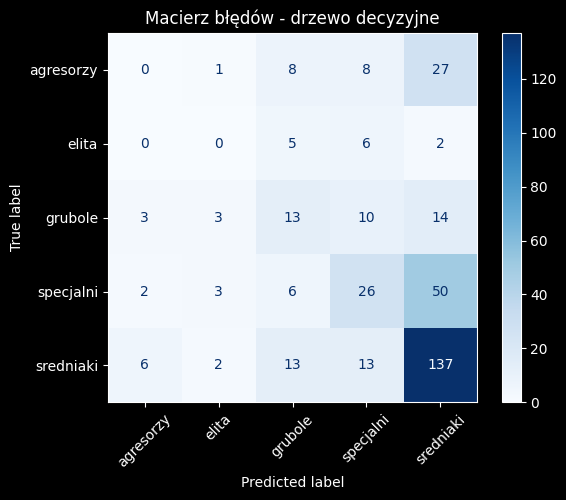

In [125]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów - drzewo decyzyjne")
plt.savefig("confusion_matrix_test_drzewo.png", dpi=300, bbox_inches="tight")
plt.show()

1. Skrypt z wykładów PW: *Uczenie maszynowe: Drzewa decyzyjne* (P. Cichosz).
2. Skrypt z wykładów UW: *Eksploracja Danych: Drzewa decyzyjne* (H. S. Nguyen).
3. Materiały dydaktyczne PWr: *Sztuczna Inteligencja: Drzewa decyzyjne* (W. Paluszyński).

